# Milestone 1 Closed-Loop Reentry Simulation

This notebook wires together the updated milestone 1 modules:

control -> RCS -> torque -> attitude update -> sigma_actual -> aero -> translation

The translational state convention is:

[r, phi, lam, V, gamma, chi]


In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import constants
import AtmosphereModel

from ReactionControl import build_orion_cm_rcs_12
from control import (
    CapsuleControlConfig,
    GuidanceScheduler,
    SimpleBankGuidance,
    BasicObservationProvider,
    BankActuatorLimits,
    BankActuator,
    RollTorqueController,
    CapsuleControlStack,
)
from point_math_3d import (
    make_initial_capsule_attitude,
    make_control_step_fn,
    step_closed_loop_milestone1,
)

plt.rcParams["figure.figsize"] = (10, 5)

## basic simulation timing

In [3]:
# Basic simulation timing
dt_s = constants.ENTRY_DT_S
max_steps = 800

# Vehicle and aerodynamic parameters
# These keys must match the names expected by point_math_3d and math_3d
params = {
    "mass_kg": constants.CAPSULE_MASS_KG,
    "ref_area_m2": constants.CAPSULE_REFERENCE_AREA_M2,
    "CL_const": 0.32,
    "CD_const": 1.05,
}

# Print the parameter set for a quick sanity check
params

{'mass_kg': 8500.0,
 'ref_area_m2': 19.634954084936208,
 'CL_const': 0.32,
 'CD_const': 1.05}

## high level control stack

In [4]:
# Build the high level control stack

control_cfg = CapsuleControlConfig(
    guidance_period_s=constants.GUIDANCE_PERIOD_S
)

scheduler = GuidanceScheduler(
    period_s=constants.GUIDANCE_PERIOD_S
)

# Use a high velocity enable threshold so guidance is active immediately
# during early integration testing
guidance = SimpleBankGuidance(
    max_bank_deg=70.0,
    min_bank_deg=40.0,
    downrange_gain=1e-6,
    velocity_enable_mps=20_000.0,
)

# Small target offset so the guidance law creates a nonzero bank request
target_phi_rad = math.radians(0.4)
target_lam_rad = math.radians(1.5)

obs_provider = BasicObservationProvider(
    target_phi_rad=target_phi_rad,
    target_lam_rad=target_lam_rad,
    params=params,
)

actuator_limits = BankActuatorLimits(
    sigma_rate_max_rps=math.radians(20.0),
    sigma_accel_max_rps2=math.radians(60.0),
)

bank_actuator = BankActuator(actuator_limits)

roll_controller = RollTorqueController(
    kp_Nm_per_rad=constants.ROLL_KP_NM_PER_RAD,
    kd_Nm_per_rad_s=constants.ROLL_KD_NM_PER_RAD_S,
    max_torque_Nm=constants.ROLL_CMD_MAX_TORQUE_NM,
)

control_stack = CapsuleControlStack(
    cfg=control_cfg,
    scheduler=scheduler,
    guidance=guidance,
    obs_provider=obs_provider,
    bank_actuator=bank_actuator,
    roll_controller=roll_controller,
)

control_stack.reset()

## instantiate v1 (milestone 1) RCS system

In [5]:
# Build the milestone 1 RCS system
rcs = build_orion_cm_rcs_12()
rcs.reset()

# Quick look at the available thruster names
rcs.names()

['POD0_AX',
 'POD0_RPOS',
 'POD0_RNEG',
 'POD1_AX',
 'POD1_RPOS',
 'POD1_RNEG',
 'POD2_AX',
 'POD2_RPOS',
 'POD2_RNEG',
 'POD3_AX',
 'POD3_RPOS',
 'POD3_RNEG']

### initial transition state

In [6]:
# Initial translational state
# x_trans = [r, phi, lam, V, gamma, chi]

initial_altitude_m = 80_000.0
initial_phi_rad = math.radians(0.0)
initial_lam_rad = math.radians(0.0)
initial_speed_mps = 5_500.0
initial_gamma_rad = math.radians(-5.0)
initial_chi_rad = math.radians(0.0)

x_trans = [
    constants.RADIUS_EARTH + initial_altitude_m,
    initial_phi_rad,
    initial_lam_rad,
    initial_speed_mps,
    initial_gamma_rad,
    initial_chi_rad,
]

# Initial capsule attitude
att = make_initial_capsule_attitude(sigma0_rad=0.0)

x_trans, att

([6458100.0, 0.0, 0.0, 5500.0, -0.08726646259971647, 0.0],
 CapsuleAttitudeState(q_ba=[1.0, 0.0, 0.0, 0.0], omega_b_rad_s=[0.0, 0.0, 0.0], sigma_rel_rad=0.0))

## build the control bridge function used by miletsone 1 closed loop step

In [7]:
# Build the control bridge function used by the milestone 1 closed loop step
# point_math_3d owns the nominal aerodynamic model now, so use aero_forces from there

from point_math_3d import aero_forces

control_step_fn = make_control_step_fn(
    control=control_stack,
    aero_force_fn=aero_forces,
    params=params,
    dt_s=dt_s,
)

In [8]:
# Rebuild control_step_fn using the nominal aerodynamic force function
# point_math_3d now owns the float translational dynamics and float aero model
# so the control bridge should reference that module instead of math_3d

from point_math_3d import aero_forces

control_step_fn = make_control_step_fn(
    control=control_stack,
    aero_force_fn=aero_forces,
    params=params,
    dt_s=dt_s,
)

control_step_fn

<function point_math_3d.make_control_step_fn.<locals>.control_step_fn(t: float, x: List[float], sigma_actual_rad: float, roll_rate_rad_s: float)>

# Run the milestone 1 closed-loop simulation

In [9]:
# Run the milestone 1 closed loop simulation with interval supervisor annotations
# The nominal path remains the primary simulator path
# The interval path provides a bounded local uncertainty envelope around each nominal step

from math_3d import (
    IntervalSupervisorConfig,
    inflate_nominal_state_to_interval_box,
    annotate_nominal_state_with_interval_supervisor,
)

logs = []

# Use small angular half widths so cosine terms stay well away from zero
# This helps prevent interval reciprocals from becoming undefined
interval_cfg = IntervalSupervisorConfig(
    r_half_width_m=25.0,
    phi_half_width_rad=1e-6,
    lam_half_width_rad=1e-6,
    V_half_width_mps=10.0,
    gamma_half_width_rad=1e-4,
    chi_half_width_rad=1e-4,
    include_heating=True,
)

t_s = 0.0

# Start the interval supervisor from an inflated version of the initial nominal state
x_interval = inflate_nominal_state_to_interval_box(x_trans, interval_cfg)

for step_idx in range(max_steps):
    result = step_closed_loop_milestone1(
        t_s=t_s,
        x_trans=x_trans,
        att=att,
        params=params,
        control_step_fn=control_step_fn,
        rcs=rcs,
        dt_s=dt_s,
        Izz_kgm2=constants.CAPSULE_IZZ_KGM2,
    )

    # The interval supervisor uses the actual bank angle produced by the nominal path
    # This keeps control and RCS float based while the interval path only annotates translation
    interval_result = annotate_nominal_state_with_interval_supervisor(
        x_nominal_old=result.x_old,
        params=params,
        sigma_actual_after_rad=result.sigma_actual_after_rad,
        x_interval_old=x_interval,
        supervisor_cfg=interval_cfg,
        dt_s=dt_s,
        t_s=t_s,
    )

    # Advance the nominal path
    x_trans = result.x_new
    att = result.att_new

    # Re center the interval box around the latest nominal state each step
    # This keeps the supervisor local and prevents the interval box from growing without bound
    x_interval = inflate_nominal_state_to_interval_box(x_trans, interval_cfg)

    r_m = x_trans[0]
    phi_rad = x_trans[1]
    lam_rad = x_trans[2]
    speed_mps = x_trans[3]
    altitude_m = r_m - constants.RADIUS_EARTH

    logs.append({
        "step": step_idx,
        "time_s": t_s,
        "r_m": r_m,
        "phi_rad": phi_rad,
        "lam_rad": lam_rad,
        "V_mps": x_trans[3],
        "gamma_rad": x_trans[4],
        "chi_rad": x_trans[5],
        "sigma_cmd_rad": result.control_out.sigma_cmd_rad,
        "sigma_target_rad": result.control_out.sigma_target_rad,
        "sigma_actual_before_rad": result.sigma_actual_before_rad,
        "sigma_actual_after_rad": result.sigma_actual_after_rad,
        "roll_rate_rad_s": result.att_new.omega_b_rad_s[2],
        "tau_roll_cmd_Nm": result.control_out.tau_roll_cmd_Nm,
        "active_thrusters": ", ".join(result.roll_step.fire_cmd.active_names()),
        "thrusters_fired": result.roll_step.fired_this_step,
        "requested_duty": result.roll_step.requested_duty,
        "tau_roll_capacity_Nm": result.roll_step.tau_roll_capacity_Nm,
        "altitude_m": altitude_m,
        "speed_mps": speed_mps,

        "r_iv_lo": interval_result.x_interval_new[0].lo,
        "r_iv_hi": interval_result.x_interval_new[0].hi,
        "phi_iv_lo": interval_result.x_interval_new[1].lo,
        "phi_iv_hi": interval_result.x_interval_new[1].hi,
        "lam_iv_lo": interval_result.x_interval_new[2].lo,
        "lam_iv_hi": interval_result.x_interval_new[2].hi,
        "V_iv_lo": interval_result.x_interval_new[3].lo,
        "V_iv_hi": interval_result.x_interval_new[3].hi,
        "gamma_iv_lo": interval_result.x_interval_new[4].lo,
        "gamma_iv_hi": interval_result.x_interval_new[4].hi,
        "chi_iv_lo": interval_result.x_interval_new[5].lo,
        "chi_iv_hi": interval_result.x_interval_new[5].hi,

        "r_width": interval_result.state_widths_new["r"],
        "phi_width": interval_result.state_widths_new["phi"],
        "lam_width": interval_result.state_widths_new["lam"],
        "V_width": interval_result.state_widths_new["V"],
        "gamma_width": interval_result.state_widths_new["gamma"],
        "chi_width": interval_result.state_widths_new["chi"],

        "rho_iv_lo": interval_result.rho_interval.lo,
        "rho_iv_hi": interval_result.rho_interval.hi,
        "q_iv_lo": interval_result.q_interval.lo,
        "q_iv_hi": interval_result.q_interval.hi,

        "sigma_iv_lo": interval_result.sigma_interval_used.lo,
        "sigma_iv_hi": interval_result.sigma_interval_used.hi,

        "altitude_iv_lo": interval_result.altitude_interval.lo,
        "altitude_iv_hi": interval_result.altitude_interval.hi,

        "safety_status": interval_result.safety_status,
        "layer_indices": ",".join(str(k) for k in interval_result.layer_indices),

        "heating_qdot_max_lo": (
            interval_result.heating_qdot_max_interval.lo
            if interval_result.heating_qdot_max_interval is not None else np.nan
        ),
        "heating_qdot_max_hi": (
            interval_result.heating_qdot_max_interval.hi
            if interval_result.heating_qdot_max_interval is not None else np.nan
        ),
        "heating_qdot_mean_lo": (
            interval_result.heating_qdot_mean_interval.lo
            if interval_result.heating_qdot_mean_interval is not None else np.nan
        ),
        "heating_qdot_mean_hi": (
            interval_result.heating_qdot_mean_interval.hi
            if interval_result.heating_qdot_mean_interval is not None else np.nan
        ),
        "heating_Q_max_lo": (
            interval_result.heating_Q_max_interval.lo
            if interval_result.heating_Q_max_interval is not None else np.nan
        ),
        "heating_Q_max_hi": (
            interval_result.heating_Q_max_interval.hi
            if interval_result.heating_Q_max_interval is not None else np.nan
        ),
    })

    t_s += dt_s

    if altitude_m <= 0.0:
        print(f"Stopping: altitude reached ground at step {step_idx}")
        break

    if speed_mps <= 10.0:
        print(f"Stopping: speed dropped below threshold at step {step_idx}")
        break

Stopping: altitude reached ground at step 318


In [10]:
# Convert logs to a DataFrame
df = pd.DataFrame(logs)

# Display the first few rows
df.head()

,step,time_s,r_m,phi_rad,lam_rad,V_mps,gamma_rad,chi_rad,sigma_cmd_rad,sigma_target_rad,...,altitude_iv_lo,altitude_iv_hi,safety_status,layer_indices,heating_qdot_max_lo,heating_qdot_max_hi,heating_qdot_mean_lo,heating_qdot_mean_hi,heating_Q_max_lo,heating_Q_max_hi
0,0,0.00,6.457980e+06,0.000000e+00,0.000212,5500.274354,-0.087486,0.000000e+00,-0.865106,-0.065450,...,79975.000000,80025.000000,not_evaluated,6,24655.222768,130468.205796,66179.808482,67210.893895,6163.805692,32617.051449
1,1,0.25,6.457860e+06,0.000000e+00,0.000424,5500.550545,-0.087706,0.000000e+00,-0.865106,-0.152716,...,79855.160854,79905.160854,not_evaluated,6,24893.319122,131727.365723,66818.909222,67859.552039,6223.329781,32931.841431
2,2,0.50,6.457740e+06,0.000000e+00,0.000636,5500.828601,-0.087926,0.000000e+00,-0.865106,-0.239983,...,79735.014582,79785.014582,not_evaluated,6,25134.077543,133000.596865,67465.155509,68515.458991,6283.519386,33250.149216
3,3,0.75,6.457619e+06,0.000000e+00,0.000848,5501.108541,-0.088146,1.773408e-07,-0.865106,-0.327249,...,79614.561177,79664.561177,not_evaluated,6,25377.529685,134288.066461,68118.632312,69178.700904,6344.382421,33572.016615
4,4,1.00,6.457498e+06,3.762159e-11,0.001061,5501.390376,-0.088365,5.387929e-07,-0.859694,-0.414516,...,79493.800633,79543.800633,not_evaluated,6,25623.707486,135589.943244,68779.425357,69849.364701,6405.926872,33897.485811


# visual analysis

## non trajectory control effectiveness

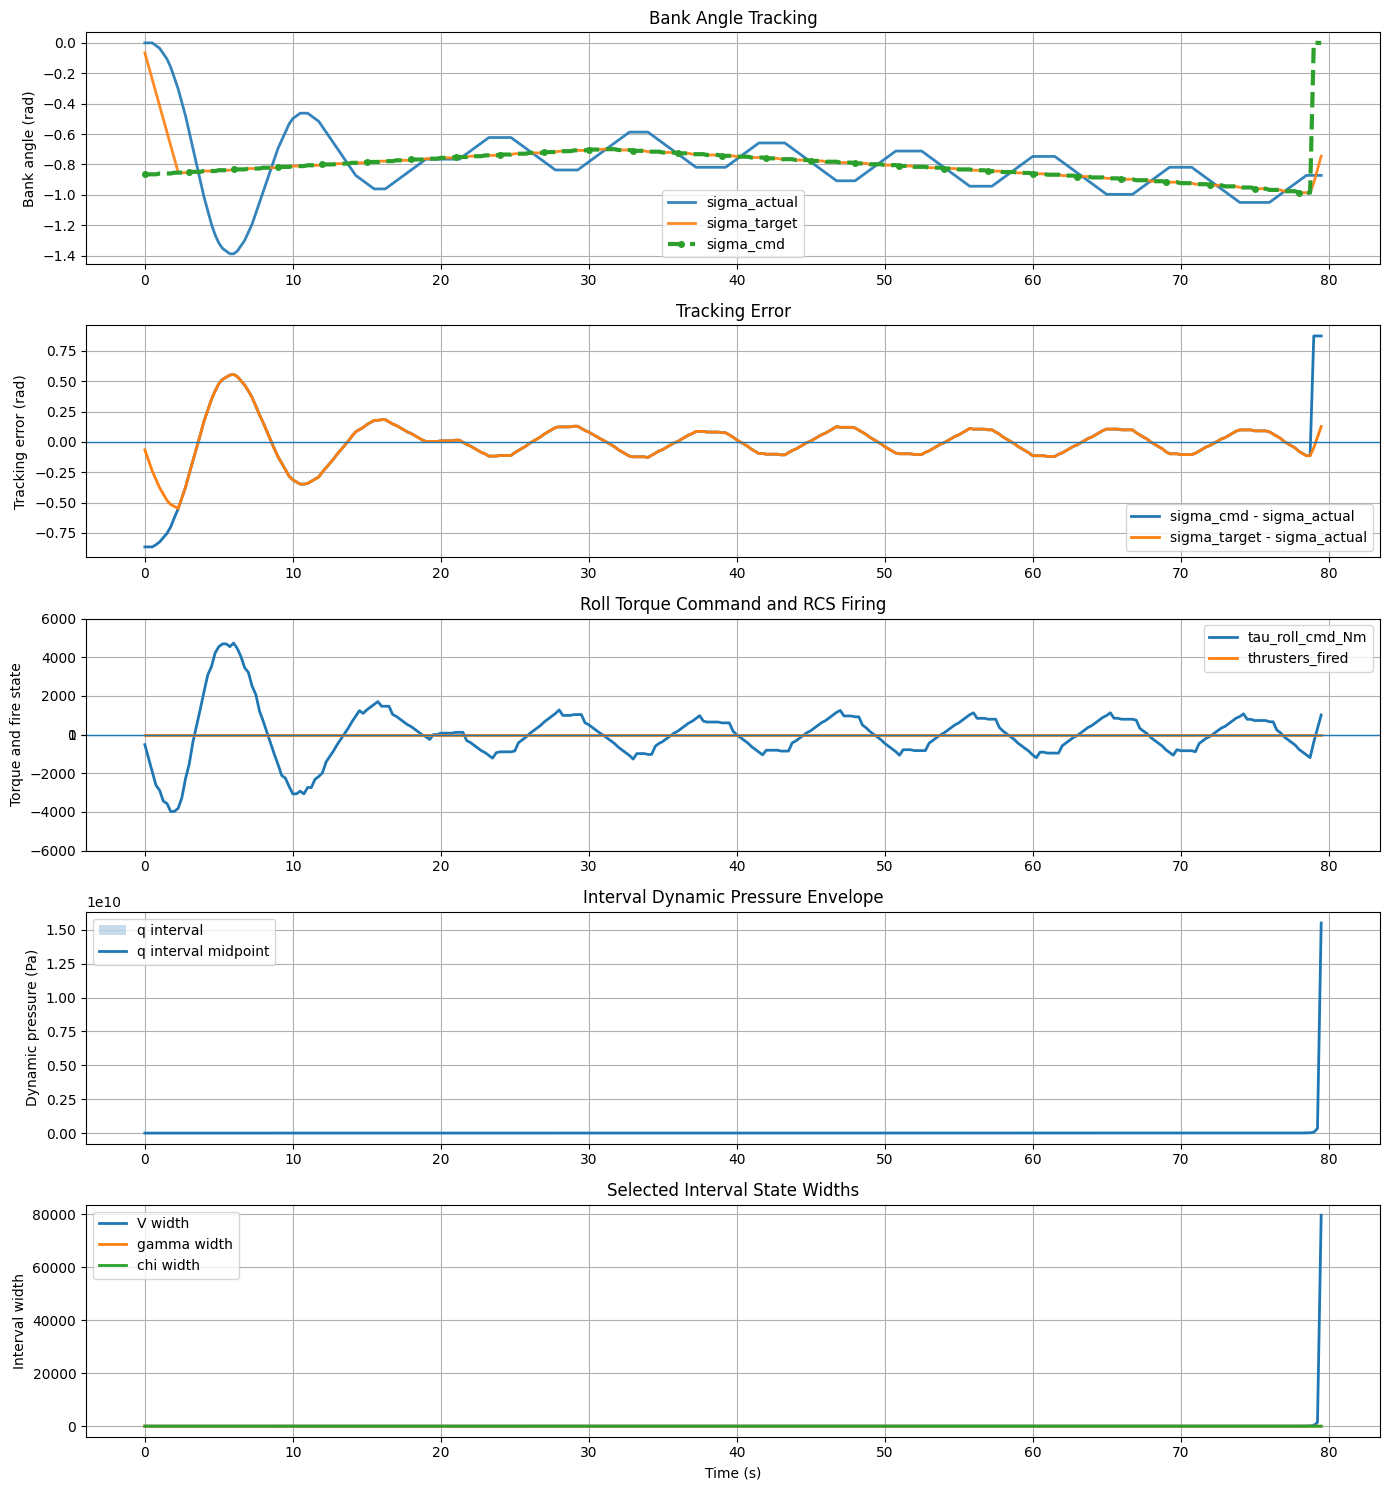

Control and supervisor summary
RMSE between sigma_target and sigma_actual: 0.159431 rad
RMSE between sigma_cmd and sigma_actual: 0.215327 rad
Total firing steps: 52
Maximum absolute commanded torque: 4731.035 N m
Maximum q interval width: 127813622.528984 Pa
Maximum V interval width: 79622.059176
Maximum gamma interval width: 0.115284
Maximum chi interval width: 0.087559


In [11]:
# Non trajectory control effectiveness plots for bank angle, RCS, and interval supervisor outputs
# This version keeps the bank tracking view and adds the interval width and q envelope

required_cols = [
    "time_s",
    "sigma_cmd_rad",
    "sigma_target_rad",
    "sigma_actual_after_rad",
    "tau_roll_cmd_Nm",
    "thrusters_fired",
    "q_iv_lo",
    "q_iv_hi",
    "V_width",
    "gamma_width",
    "chi_width",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"DataFrame is missing required columns: {missing}")

time_s = df["time_s"].to_numpy()
sigma_cmd = df["sigma_cmd_rad"].to_numpy()
sigma_target = df["sigma_target_rad"].to_numpy()
sigma_actual = df["sigma_actual_after_rad"].to_numpy()
tau_roll_cmd = df["tau_roll_cmd_Nm"].to_numpy()
thrusters_fired = df["thrusters_fired"].astype(int).to_numpy()

q_iv_lo = df["q_iv_lo"].to_numpy()
q_iv_hi = df["q_iv_hi"].to_numpy()
q_iv_mid = 0.5 * (q_iv_lo + q_iv_hi)
q_iv_width = q_iv_hi - q_iv_lo

V_width = df["V_width"].to_numpy()
gamma_width = df["gamma_width"].to_numpy()
chi_width = df["chi_width"].to_numpy()

# Tracking errors
cmd_minus_actual = sigma_cmd - sigma_actual
target_minus_actual = sigma_target - sigma_actual

# Simple effectiveness metrics
rmse_target_actual = np.sqrt(np.mean(target_minus_actual ** 2))
rmse_cmd_actual = np.sqrt(np.mean(cmd_minus_actual ** 2))

# Create figure
fig = plt.figure(figsize=(14, 15))

# 1. Command, target, actual bank angle
# sigma_cmd is drawn thicker so the guidance command is easy to distinguish
ax1 = fig.add_subplot(5, 1, 1)
ax1.plot(
    time_s,
    sigma_actual,
    label="sigma_actual",
    linewidth=2.0,
    alpha=0.9,
    zorder=2,
)
ax1.plot(
    time_s,
    sigma_target,
    label="sigma_target",
    linewidth=2.0,
    alpha=0.9,
    zorder=3,
)
ax1.plot(
    time_s,
    sigma_cmd,
    label="sigma_cmd",
    linewidth=3.0,
    linestyle="--",
    marker="o",
    markersize=4,
    markevery=max(1, len(time_s) // 25),
    zorder=5,
)

ax1.set_ylabel("Bank angle (rad)")
ax1.set_title("Bank Angle Tracking")
ax1.grid(True)
ax1.legend()

# 2. Tracking errors
ax2 = fig.add_subplot(5, 1, 2, sharex=ax1)
ax2.plot(time_s, cmd_minus_actual, label="sigma_cmd - sigma_actual", linewidth=2.0)
ax2.plot(time_s, target_minus_actual, label="sigma_target - sigma_actual", linewidth=2.0)
ax2.axhline(0.0, linewidth=1)
ax2.set_ylabel("Tracking error (rad)")
ax2.set_title("Tracking Error")
ax2.grid(True)
ax2.legend()

# 3. Torque command and RCS firing activity
# The step trace shows when the roll channel actually fired during the fixed time step simulation
ax3 = fig.add_subplot(5, 1, 3, sharex=ax1)
ax3.plot(time_s, tau_roll_cmd, linewidth=2.0, label="tau_roll_cmd_Nm")
ax3.step(time_s, thrusters_fired, where="post", linewidth=2.0, label="thrusters_fired")
ax3.axhline(0.0, linewidth=1)
ax3.set_ylabel("Torque and fire state")
ax3.set_title("Roll Torque Command and RCS Firing")
ax3.set_yticks([0, 1] + [tick for tick in ax3.get_yticks() if tick not in [0, 1]])
ax3.grid(True)
ax3.legend()

# 4. Dynamic pressure interval envelope
# The filled region shows the uncertainty envelope produced by the interval supervisor
ax4 = fig.add_subplot(5, 1, 4, sharex=ax1)
ax4.fill_between(time_s, q_iv_lo, q_iv_hi, alpha=0.25, label="q interval")
ax4.plot(time_s, q_iv_mid, linewidth=2.0, label="q interval midpoint")
ax4.set_ylabel("Dynamic pressure (Pa)")
ax4.set_title("Interval Dynamic Pressure Envelope")
ax4.grid(True)
ax4.legend()

# 5. Interval width growth for selected states
# These widths are useful for checking whether the supervisor envelope remains local and well behaved
ax5 = fig.add_subplot(5, 1, 5, sharex=ax1)
ax5.plot(time_s, V_width, linewidth=2.0, label="V width")
ax5.plot(time_s, gamma_width, linewidth=2.0, label="gamma width")
ax5.plot(time_s, chi_width, linewidth=2.0, label="chi width")
ax5.set_ylabel("Interval width")
ax5.set_xlabel("Time (s)")
ax5.set_title("Selected Interval State Widths")
ax5.grid(True)
ax5.legend()

plt.tight_layout()
plt.show()

print("Control and supervisor summary")
print(f"RMSE between sigma_target and sigma_actual: {rmse_target_actual:.6f} rad")
print(f"RMSE between sigma_cmd and sigma_actual: {rmse_cmd_actual:.6f} rad")
print(f"Total firing steps: {int(np.sum(thrusters_fired))}")
print(f"Maximum absolute commanded torque: {float(np.max(np.abs(tau_roll_cmd))):.3f} N m")
print(f"Maximum q interval width: {float(np.max(q_iv_width)):.6f} Pa")
print(f"Maximum V interval width: {float(np.max(V_width)):.6f}")
print(f"Maximum gamma interval width: {float(np.max(gamma_width)):.6f}")
print(f"Maximum chi interval width: {float(np.max(chi_width)):.6f}")

## effective control duration for the RCS

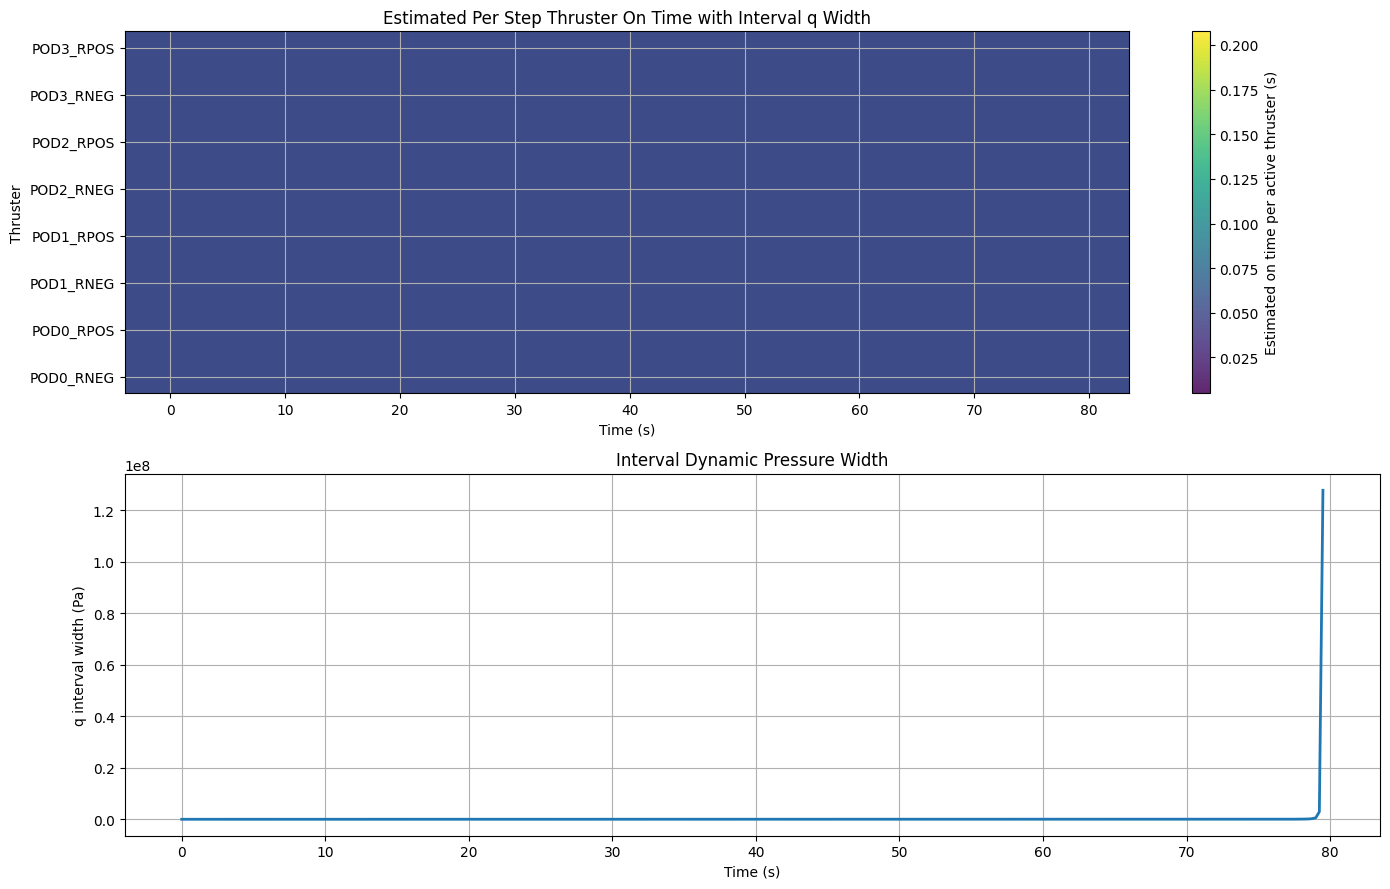

Interpretation:
Each dot means that thruster was active during that simulation step.
Dot color shows estimated on time equal to requested_duty times 0.25 s.
Dot size shows the interval dynamic pressure width at that same time step.
This remains a step level estimate and not an independently logged per thruster hardware pulse width.


In [12]:
# Scatter plot of estimated per step thruster activity
# This view keeps the thruster timeline but also shows the interval supervisor width at each firing event
# The on time is still an estimated per step value based on requested duty, not a separately logged hardware pulse width

required_cols = [
    "time_s",
    "active_thrusters",
    "requested_duty",
    "thrusters_fired",
    "q_iv_lo",
    "q_iv_hi",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"DataFrame is missing required columns: {missing}")

dt_s = constants.ENTRY_DT_S

records = []

for _, row in df.iterrows():
    t = float(row["time_s"])
    duty = float(row["requested_duty"])
    fired = bool(row["thrusters_fired"])

    # Estimated on time during this simulation step
    # This converts the commanded duty fraction into a step level duration estimate
    on_time_s = max(0.0, duty) * dt_s

    # Dynamic pressure interval width is a useful uncertainty measure to attach
    # to each firing event because it shows how wide the supervisor envelope is
    q_width = float(row["q_iv_hi"]) - float(row["q_iv_lo"])

    active_str = row["active_thrusters"]
    if pd.isna(active_str) or str(active_str).strip() == "":
        continue

    active_list = [name.strip() for name in str(active_str).split(",") if name.strip()]

    for thr_name in active_list:
        records.append({
            "time_s": t,
            "thruster": thr_name,
            "on_time_s": on_time_s,
            "q_width": q_width,
            "fired": int(fired),
        })

thr_df = pd.DataFrame(records)

if thr_df.empty:
    print("No active thruster firings were logged.")
else:
    # Keep a stable thruster ordering
    thruster_order = sorted(thr_df["thruster"].unique())
    thruster_to_y = {name: i for i, name in enumerate(thruster_order)}

    x_vals = thr_df["time_s"].to_numpy()
    y_vals = thr_df["thruster"].map(thruster_to_y).to_numpy()
    c_vals = thr_df["on_time_s"].to_numpy()
    s_vals = 40.0 + 250.0 * thr_df["q_width"].to_numpy()

    fig = plt.figure(figsize=(14, 9))

    # Top plot shows the per thruster event timeline
    # Dot color represents estimated on time for the active thruster during that step
    # Dot size represents the interval dynamic pressure width at that same event
    ax1 = fig.add_subplot(2, 1, 1)
    sc = ax1.scatter(
        x_vals,
        y_vals,
        c=c_vals,
        s=s_vals,
        alpha=0.85,
    )

    ax1.set_yticks(range(len(thruster_order)))
    ax1.set_yticklabels(thruster_order)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Thruster")
    ax1.set_title("Estimated Per Step Thruster On Time with Interval q Width")
    ax1.grid(True)

    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label("Estimated on time per active thruster (s)")

    # Bottom plot shows the interval q width over time so the supervisor envelope
    # can be compared directly against the firing pattern above
    ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)
    q_width_by_step = df["q_iv_hi"].to_numpy() - df["q_iv_lo"].to_numpy()
    ax2.plot(df["time_s"].to_numpy(), q_width_by_step, linewidth=2.0)
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("q interval width (Pa)")
    ax2.set_title("Interval Dynamic Pressure Width")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("Each dot means that thruster was active during that simulation step.")
    print(f"Dot color shows estimated on time equal to requested_duty times {dt_s:.2f} s.")
    print("Dot size shows the interval dynamic pressure width at that same time step.")
    print("This remains a step level estimate and not an independently logged per thruster hardware pulse width.")

### speed vs time

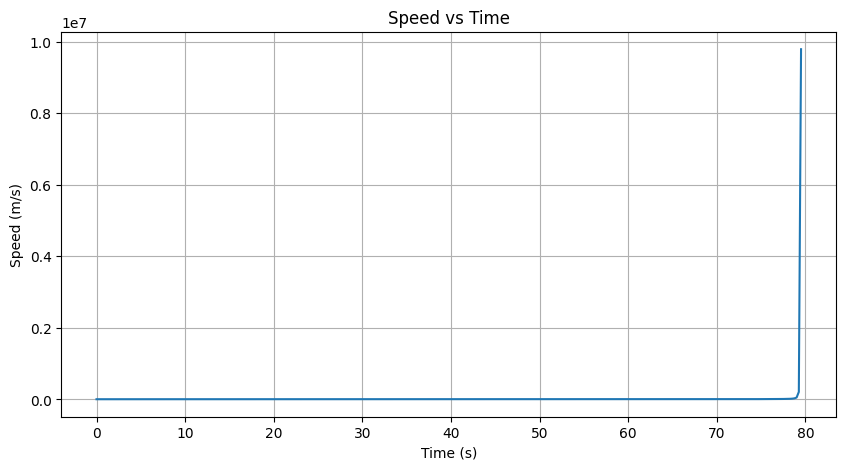

In [13]:
# Plot speed versus time

plt.figure()
plt.plot(df["time_s"], df["speed_mps"])
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Speed vs Time")
plt.grid(True)
plt.show()

### altitude vs time

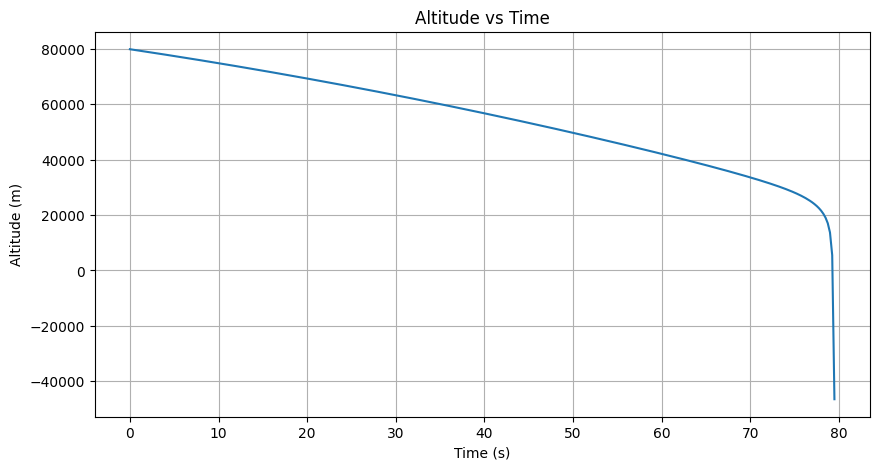

In [14]:
# Plot altitude versus time

plt.figure()
plt.plot(df["time_s"], df["altitude_m"])
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.title("Altitude vs Time")
plt.grid(True)
plt.show()

# 3D trajectory view - earth coordinate axes

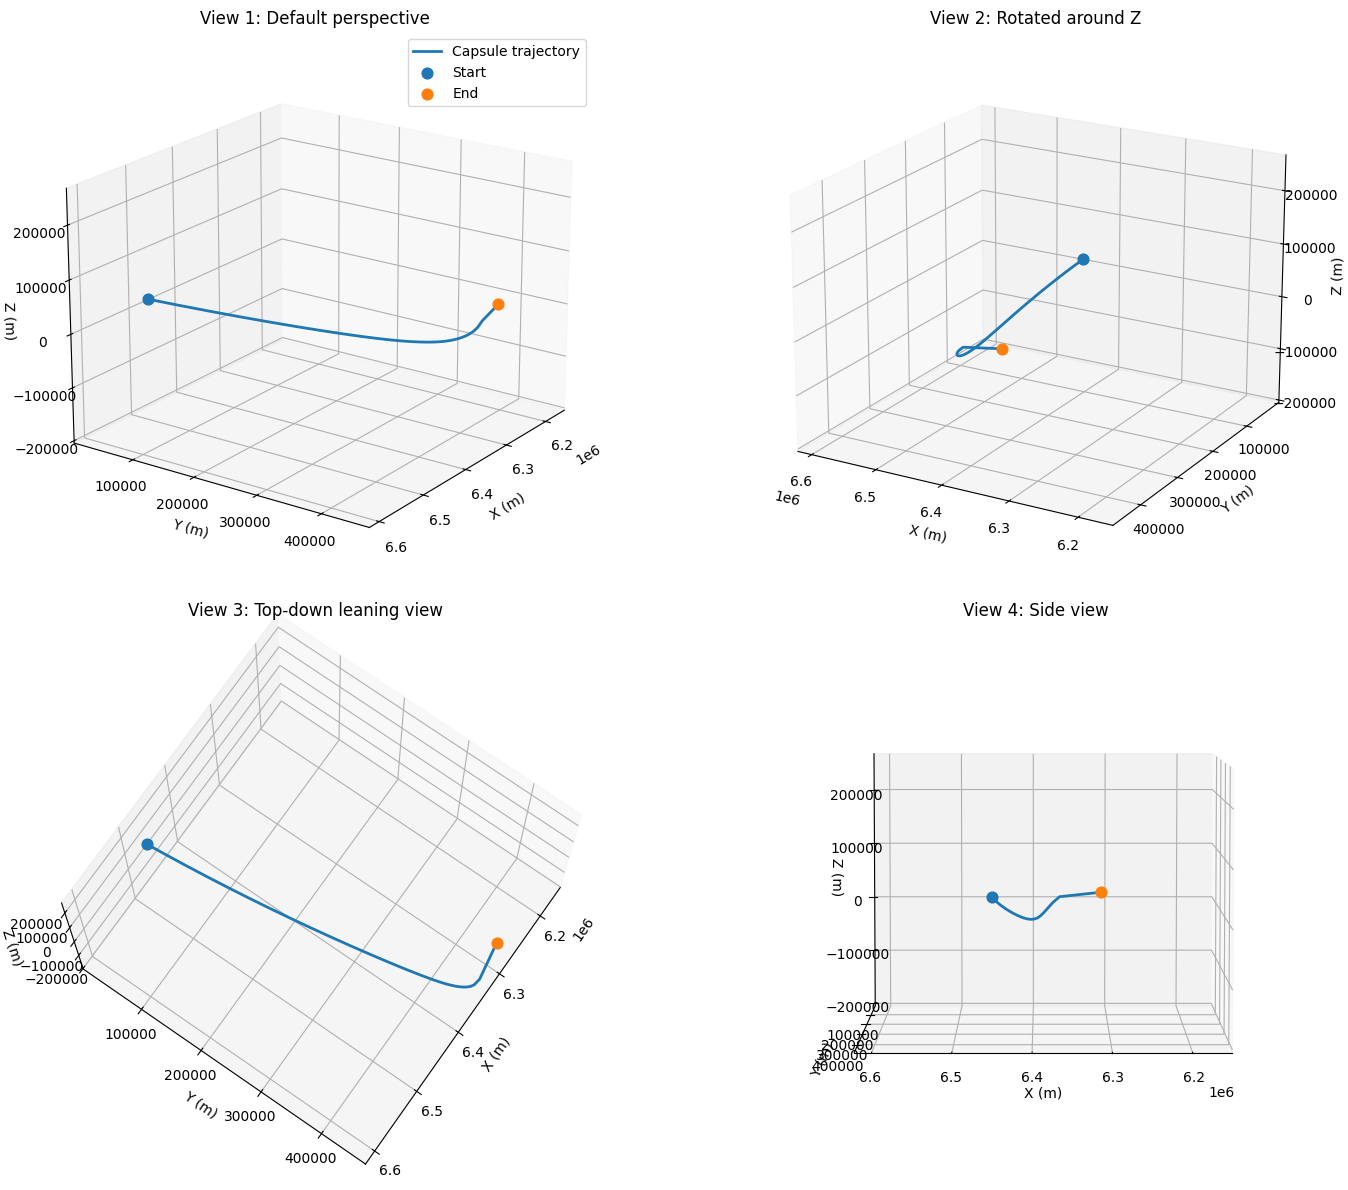

In [15]:
# Plot the capsule trajectory in 3D from multiple viewing angles

from mpl_toolkits.mplot3d import Axes3D

if "r_m" not in df.columns or "phi_rad" not in df.columns or "lam_rad" not in df.columns:
    raise ValueError("DataFrame must contain 'r_m', 'phi_rad', and 'lam_rad' columns.")

r_vals = df["r_m"].to_numpy()
phi_vals = df["phi_rad"].to_numpy()
lam_vals = df["lam_rad"].to_numpy()

# Earth-centered Cartesian coordinates
x_w = r_vals * np.cos(phi_vals) * np.cos(lam_vals)
y_w = r_vals * np.cos(phi_vals) * np.sin(lam_vals)
z_w = r_vals * np.sin(phi_vals)

# Axis limits with equal scaling
x_min, x_max = np.min(x_w), np.max(x_w)
y_min, y_max = np.min(y_w), np.max(y_w)
z_min, z_max = np.min(z_w), np.max(z_w)

x_mid = 0.5 * (x_min + x_max)
y_mid = 0.5 * (y_min + y_max)
z_mid = 0.5 * (z_min + z_max)

max_range = 0.5 * max(x_max - x_min, y_max - y_min, z_max - z_min)

views = [
    (20, 35, "View 1: Default perspective"),
    (20, 120, "View 2: Rotated around Z"),
    (75, 35, "View 3: Top-down leaning view"),
    (5, 90, "View 4: Side view"),
]

fig = plt.figure(figsize=(16, 12))

for i, (elev, azim, title) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")

    ax.plot(x_w, y_w, z_w, linewidth=2, label="Capsule trajectory")
    ax.scatter(x_w[0], y_w[0], z_w[0], s=60, label="Start")
    ax.scatter(x_w[-1], y_w[-1], z_w[-1], s=60, label="End")

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_title(title)

    ax.set_xlim(x_mid - max_range, x_mid + max_range)
    ax.set_ylim(y_mid - max_range, y_mid + max_range)
    ax.set_zlim(z_mid - max_range, z_mid + max_range)

    ax.view_init(elev=elev, azim=azim)

    if i == 1:
        ax.legend()

plt.tight_layout()
plt.show()

## Ground track on a simple lat-lon map

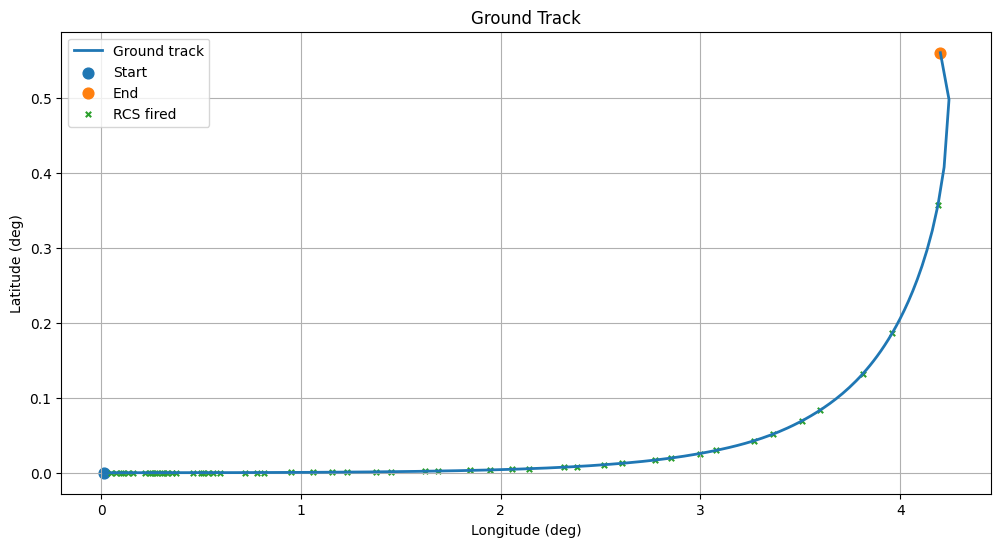

In [16]:


if "phi_rad" not in df.columns or "lam_rad" not in df.columns:
    raise ValueError("DataFrame must contain 'phi_rad' and 'lam_rad' columns.")

lat_deg = np.degrees(df["phi_rad"].to_numpy())
lon_deg = np.degrees(df["lam_rad"].to_numpy())

plt.figure(figsize=(12, 6))
plt.plot(lon_deg, lat_deg, linewidth=2, label="Ground track")
plt.scatter(lon_deg[0], lat_deg[0], s=60, label="Start")
plt.scatter(lon_deg[-1], lat_deg[-1], s=60, label="End")

# Mark where thrusters fired
if "thrusters_fired" in df.columns:
    fired = df["thrusters_fired"].to_numpy().astype(bool)
    if np.any(fired):
        plt.scatter(lon_deg[fired], lat_deg[fired], s=15, marker="x", label="RCS fired")

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Ground Track")
plt.grid(True)
plt.legend()
plt.show()

# local 3D view

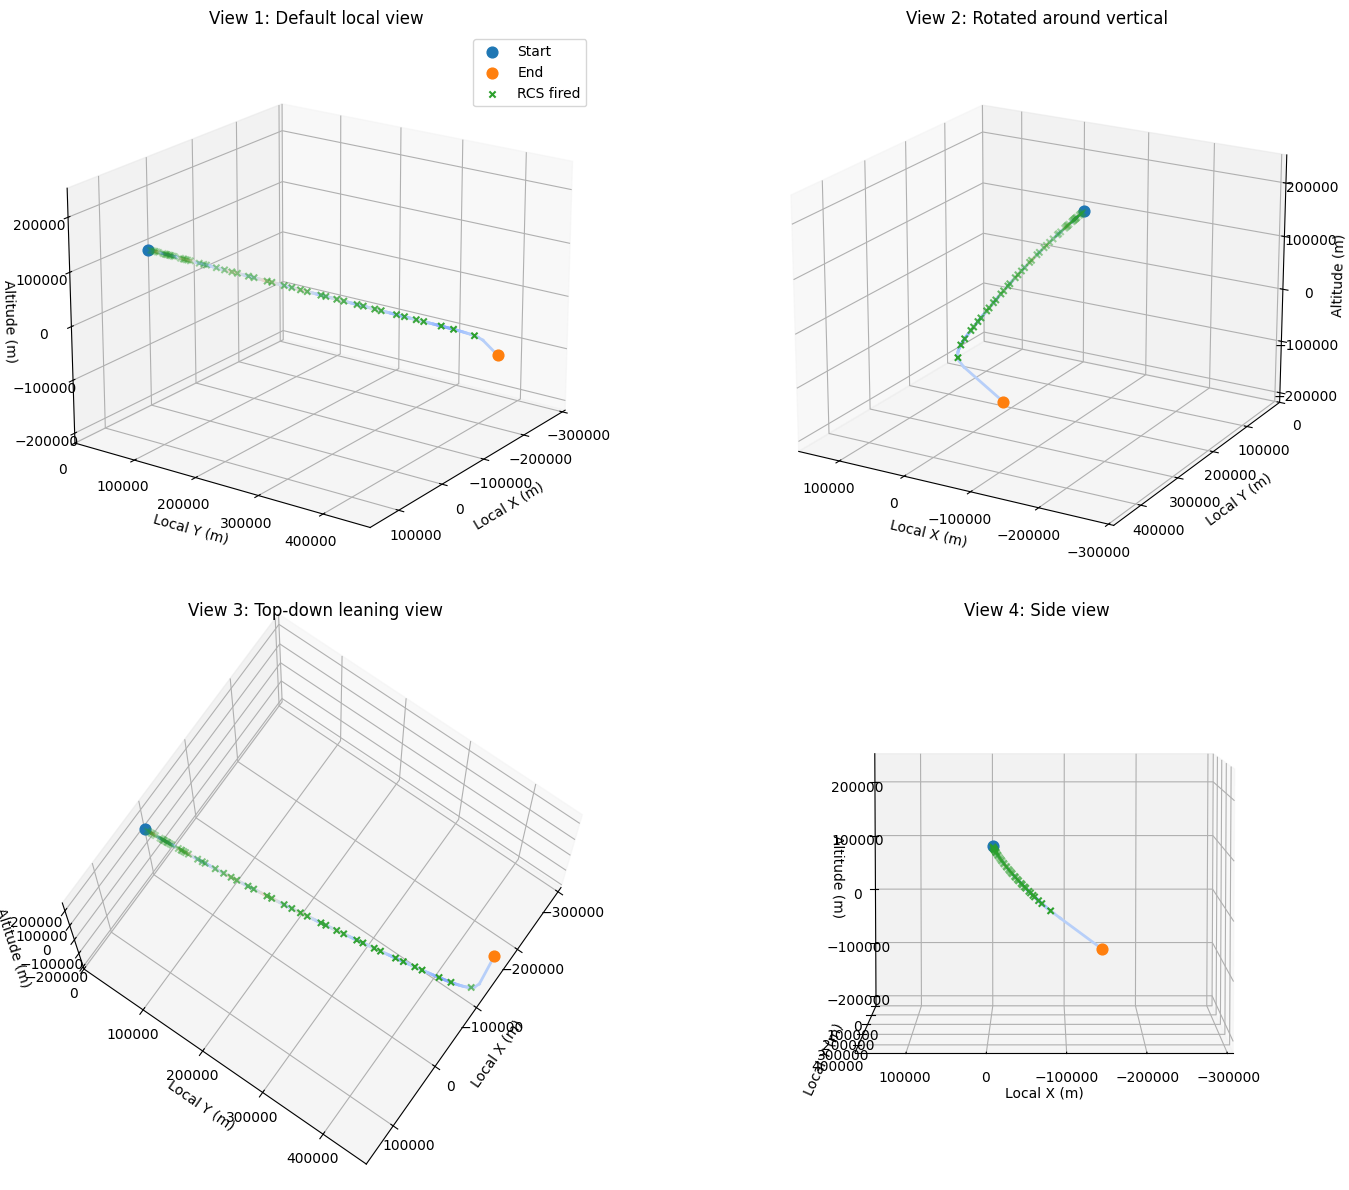

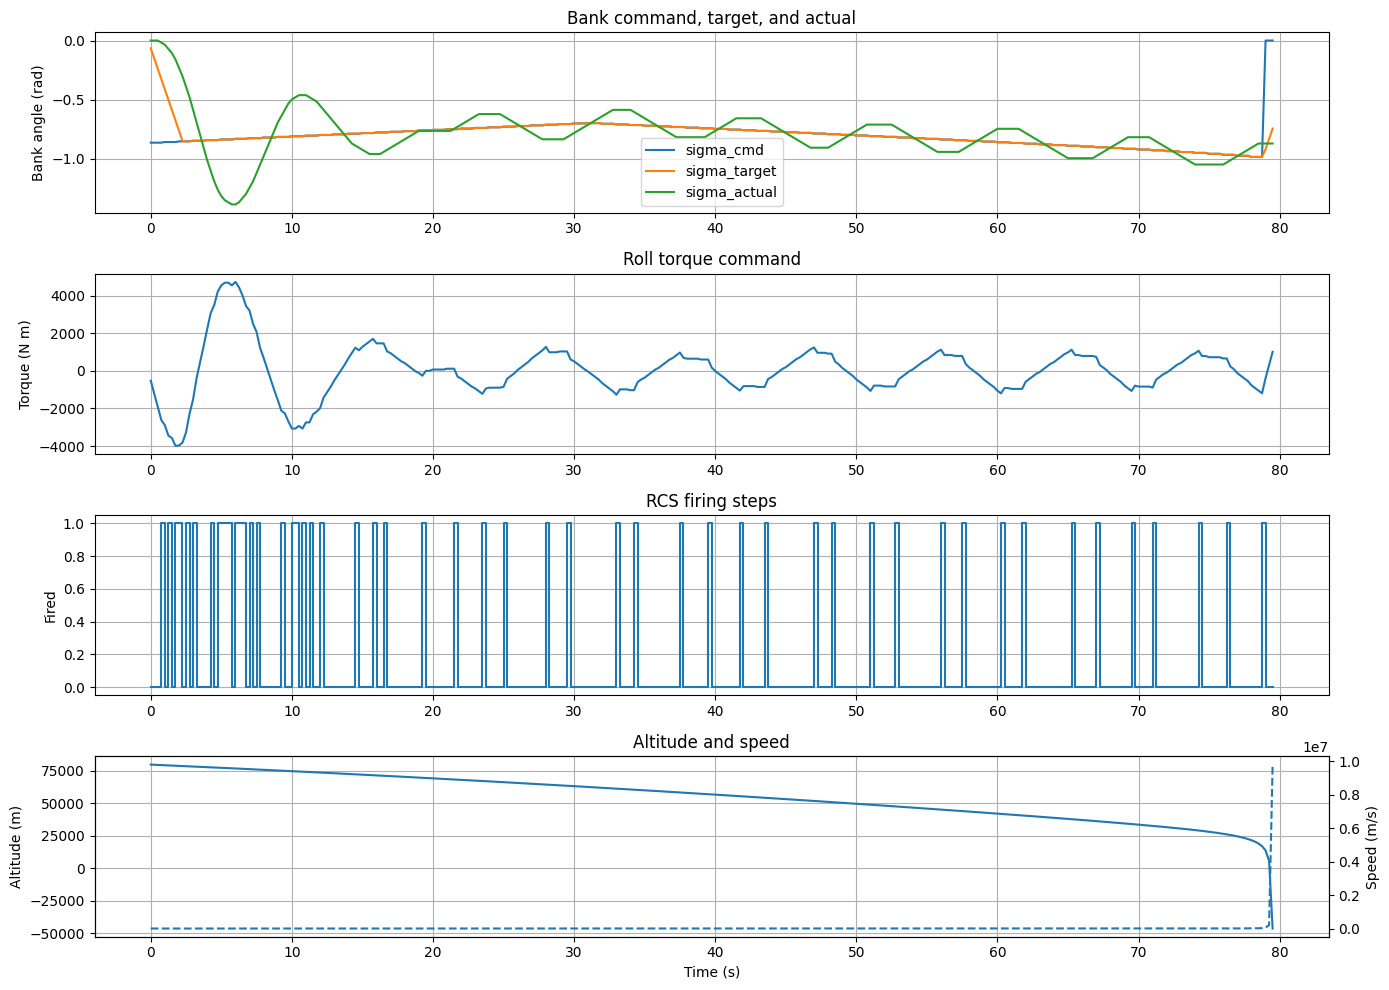

Interpretation guide
- sigma_cmd is what guidance wants
- sigma_target is the smoothed target sent to the roll controller
- sigma_actual is what the capsule actually flies after RCS and attitude dynamics
- tau_roll_cmd_Nm shows how hard the controller is trying to roll
- thrusters_fired marks the time steps where RCS jets were actually on
- If sigma_actual follows sigma_target mainly during firing windows, the RCS loop is doing its job
- If altitude goes below zero or speed blows up, the translational sim is no longer physically valid near the end


In [17]:
# Analyze how bank angle and RCS activity affect the trajectory and state history

from mpl_toolkits.mplot3d import Axes3D

required_cols = [
    "r_m", "phi_rad", "lam_rad", "altitude_m",
    "sigma_cmd_rad", "sigma_target_rad", "sigma_actual_after_rad",
    "tau_roll_cmd_Nm", "thrusters_fired"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"DataFrame is missing required columns: {missing}")

# Build local trajectory coordinates relative to the start point
r_vals = df["r_m"].to_numpy()
phi_vals = df["phi_rad"].to_numpy()
lam_vals = df["lam_rad"].to_numpy()
altitude = df["altitude_m"].to_numpy()

x_ecef = r_vals * np.cos(phi_vals) * np.cos(lam_vals)
y_ecef = r_vals * np.cos(phi_vals) * np.sin(lam_vals)
z_ecef = r_vals * np.sin(phi_vals)

x0, y0, z0 = x_ecef[0], y_ecef[0], z_ecef[0]
x_local = x_ecef - x0
y_local = y_ecef - y0

sigma_actual = df["sigma_actual_after_rad"].to_numpy()
thruster_mask = df["thrusters_fired"].to_numpy().astype(bool)

# Axis scaling for equal-looking views
x_min, x_max = np.min(x_local), np.max(x_local)
y_min, y_max = np.min(y_local), np.max(y_local)
z_min, z_max = np.min(altitude), np.max(altitude)

x_mid = 0.5 * (x_min + x_max)
y_mid = 0.5 * (y_min + y_max)
z_mid = 0.5 * (z_min + z_max)

max_range = 0.5 * max(x_max - x_min, y_max - y_min, z_max - z_min)

views = [
    (20, 35, "View 1: Default local view"),
    (20, 120, "View 2: Rotated around vertical"),
    (75, 35, "View 3: Top-down leaning view"),
    (5, 90, "View 4: Side view"),
]

fig = plt.figure(figsize=(16, 12))

for i, (elev, azim, title) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, i, projection="3d")

    # Plot path in short colored segments by actual bank angle
    for k in range(len(df) - 1):
        color_val = plt.cm.coolwarm(
            (sigma_actual[k] - np.min(sigma_actual)) /
            (np.ptp(sigma_actual) if np.ptp(sigma_actual) > 0 else 1.0)
        )
        ax.plot(
            x_local[k:k+2],
            y_local[k:k+2],
            altitude[k:k+2],
            color=color_val,
            linewidth=2
        )

    # Start and end points
    ax.scatter(x_local[0], y_local[0], altitude[0], s=60, label="Start")
    ax.scatter(x_local[-1], y_local[-1], altitude[-1], s=60, label="End")

    # RCS firing points
    if np.any(thruster_mask):
        ax.scatter(
            x_local[thruster_mask],
            y_local[thruster_mask],
            altitude[thruster_mask],
            s=20,
            marker="x",
            label="RCS fired"
        )

    ax.set_xlabel("Local X (m)")
    ax.set_ylabel("Local Y (m)")
    ax.set_zlabel("Altitude (m)")
    ax.set_title(title)

    ax.set_xlim(x_mid - max_range, x_mid + max_range)
    ax.set_ylim(y_mid - max_range, y_mid + max_range)
    ax.set_zlim(z_mid - max_range, z_mid + max_range)

    ax.view_init(elev=elev, azim=azim)

    if i == 1:
        ax.legend()

plt.tight_layout()
plt.show()

# Time-history plots for interpreting control and RCS behavior
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(4, 1, 1)
ax1.plot(df["time_s"], df["sigma_cmd_rad"], label="sigma_cmd")
ax1.plot(df["time_s"], df["sigma_target_rad"], label="sigma_target")
ax1.plot(df["time_s"], df["sigma_actual_after_rad"], label="sigma_actual")
ax1.set_ylabel("Bank angle (rad)")
ax1.set_title("Bank command, target, and actual")
ax1.grid(True)
ax1.legend()

ax2 = fig.add_subplot(4, 1, 2)
ax2.plot(df["time_s"], df["tau_roll_cmd_Nm"])
ax2.set_ylabel("Torque (N m)")
ax2.set_title("Roll torque command")
ax2.grid(True)

ax3 = fig.add_subplot(4, 1, 3)
ax3.step(df["time_s"], df["thrusters_fired"].astype(int), where="post")
ax3.set_ylabel("Fired")
ax3.set_title("RCS firing steps")
ax3.grid(True)

ax4 = fig.add_subplot(4, 1, 4)
ax4.plot(df["time_s"], df["altitude_m"], label="Altitude")
ax4_twin = ax4.twinx()
ax4_twin.plot(df["time_s"], df["speed_mps"], linestyle="--", label="Speed")
ax4.set_ylabel("Altitude (m)")
ax4_twin.set_ylabel("Speed (m/s)")
ax4.set_xlabel("Time (s)")
ax4.set_title("Altitude and speed")
ax4.grid(True)

plt.tight_layout()
plt.show()

# Text summary for interpreting what happened
print("Interpretation guide")
print("- sigma_cmd is what guidance wants")
print("- sigma_target is the smoothed target sent to the roll controller")
print("- sigma_actual is what the capsule actually flies after RCS and attitude dynamics")
print("- tau_roll_cmd_Nm shows how hard the controller is trying to roll")
print("- thrusters_fired marks the time steps where RCS jets were actually on")
print("- If sigma_actual follows sigma_target mainly during firing windows, the RCS loop is doing its job")
print("- If altitude goes below zero or speed blows up, the translational sim is no longer physically valid near the end")

## plot altitude vs ground track

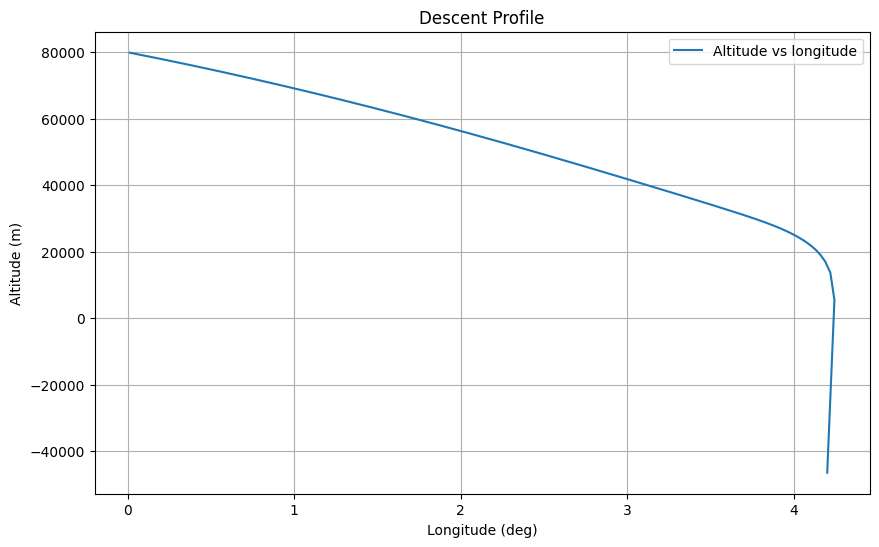

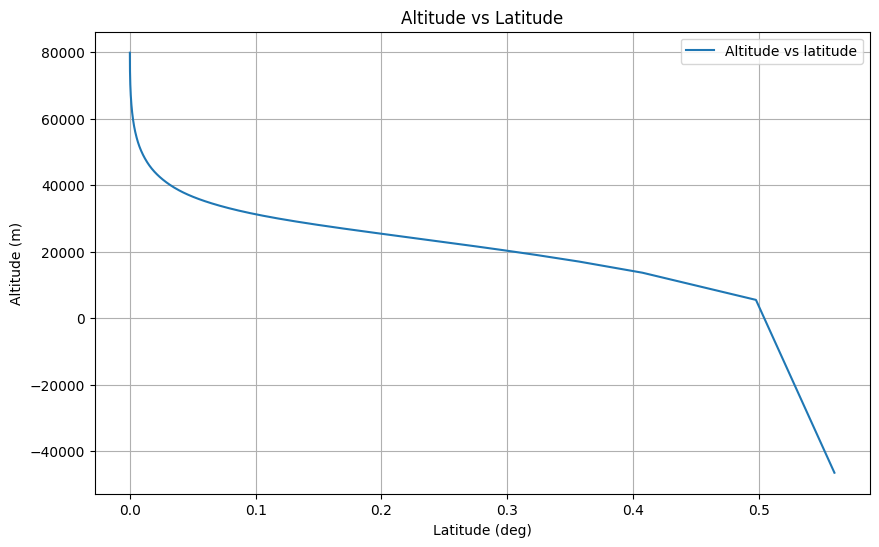

In [18]:
# Plot altitude versus ground track to make the descent easier to understand

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(df["lam_rad"]), df["altitude_m"], label="Altitude vs longitude")
plt.xlabel("Longitude (deg)")
plt.ylabel("Altitude (m)")
plt.title("Descent Profile")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(np.degrees(df["phi_rad"]), df["altitude_m"], label="Altitude vs latitude")
plt.xlabel("Latitude (deg)")
plt.ylabel("Altitude (m)")
plt.title("Altitude vs Latitude")
plt.grid(True)
plt.legend()
plt.show()

### did thrusters even fire

In [19]:
# Small diagnostic cell: did any thrusters ever fire?

thrusters_ever_fired = bool(df["thrusters_fired"].any())
fired_count = int(df["thrusters_fired"].sum())

print("Thrusters ever fired:", thrusters_ever_fired)
print("Number of steps with any thruster firing:", fired_count)

if thrusters_ever_fired:
    print("Unique active-thruster patterns seen:")
    print(df.loc[df["thrusters_fired"], "active_thrusters"].drop_duplicates().tolist())

Thrusters ever fired: True
Number of steps with any thruster firing: 52
Unique active-thruster patterns seen:
['POD0_RNEG, POD1_RNEG, POD2_RNEG, POD3_RNEG', 'POD0_RPOS, POD1_RPOS, POD2_RPOS, POD3_RPOS']


## large summary

In [20]:
# Final summary cell

final_altitude_m = float(df["altitude_m"].iloc[-1])
final_speed_mps = float(df["speed_mps"].iloc[-1])
final_sigma_actual_rad = float(df["sigma_actual_after_rad"].iloc[-1])
max_abs_roll_torque_cmd_Nm = float(df["tau_roll_cmd_Nm"].abs().max())
total_firing_steps = int(df["thrusters_fired"].sum())

print("Final summary")
print(f"final altitude: {final_altitude_m:.3f} m")
print(f"final speed: {final_speed_mps:.3f} m/s")
print(f"final sigma_actual: {final_sigma_actual_rad:.6f} rad")
print(f"maximum absolute roll torque commanded: {max_abs_roll_torque_cmd_Nm:.3f} N m")
print(f"total number of steps where any thruster fired: {total_firing_steps}")

Final summary
final altitude: -46521.472 m
final speed: 9787064.884 m/s
final sigma_actual: -0.872200 rad
maximum absolute roll torque commanded: 4731.035 N m
total number of steps where any thruster fired: 52
